<a href="https://colab.research.google.com/github/Archana-Maurya/DataScience-ML-College-Work/blob/main/Day8_2Mar_Encoding_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Scenario-Based Question
# A university wants to build a predictive model to estimate
#  student grades based on four factors:
# - Study hours per week
# - Attendance percentage
# - Previous exam score
# - Average sleep hours
# They collect data from 200 students and decide to use Ridge
#  Regression for prediction. To evaluate the model, they apply different cross-validation strategies:
# - Basic K-Fold CV (5 folds, shuffled) to check the stability of the model’s R² scores.
# - Multi-metric evaluation using both R² and Mean Squared Error (MSE), comparing training and validation
# scores.
# - Stratified K-Fold CV (for a separate classification task predicting pass/fail using Logistic
#                         Regression).

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import numpy as np

# --- Step 1: Create synthetic dataset ---
# 1000 samples, 5 features (size, bedrooms, age, distance, school rating)
X, y = make_regression(
    n_samples=1000,
    n_features=5,
    noise=15,
    random_state=42
)

# --- Step 2: Define model ---
model = LinearRegression()

# --- Step 3: Define 5-Fold CV ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Step 4: Evaluate model using R² ---
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

# --- Step 5: Print results ---
print("R² scores for each fold:", scores.round(3))
print("Mean R²:", scores.mean().round(3))
print("Std Dev:", scores.std().round(3))

# --- Step 6: Interpret results ---
if scores.std() < 0.05:
    print("Model is stable across folds.")
else:
    print("Model performance varies across folds, investigate further.")

R² scores for each fold: [0.937 0.945 0.945 0.947 0.947]
Mean R²: 0.944
Std Dev: 0.004
Model is stable across folds.


In [ ]:
# Scenario: Predicting Patient Recovery Time
# A hospital research team wants to build a model to predict patient recovery time (in days) after
#  surgery based on several factors such as:
# - Age of the patient
# - Number of hours of post-surgery physiotherapy per week
# - Pre-existing health conditions (numeric severity score)
# - Length of hospital stay (days)
# - Average sleep hours during recovery
# They collect data from 1,000 patients and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import numpy as np

# --- Step 1: Create synthetic dataset (Hospital Data) ---
# 1000 patients, 5 features:
# Age, Physiotherapy hours, Health severity score,
# Hospital stay length, Sleep hours

X, y = make_regression(
    n_samples=1000,
    n_features=5,
    noise=20,
    random_state=42
)

# --- Step 2: Define Linear Regression model ---
model = LinearRegression()

# --- Step 3: Define 5-Fold Cross Validation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Step 4: Evaluate model using R² ---
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

# --- Step 5: Print results ---
print("R² scores for each fold:", scores.round(3))
print("Mean R²:", scores.mean().round(3))
print("Standard Deviation:", scores.std().round(3))

# --- Step 6: Interpretation ---
if scores.std() < 0.05:
    print("Model is stable across folds.")
else:
    print("Model performance varies across folds. Further investigation needed.")

R² scores for each fold: [0.894 0.905 0.906 0.908 0.909]
Mean R²: 0.904
Standard Deviation: 0.005
Model is stable across folds.


In [ ]:
#Scenario: Predicting Student Exam Performance
#A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
#- Number of study hours per week
#- Attendance percentage in lectures
#-Prior GPA (Grade Point Average)
#- Participation in group projects (numeric engagement score)
#- Average sleep hours during exam preparation
#They collect data from 800 students across different departments and decide to use Linear Regression.
#To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
import numpy as np

# Step 1: Create synthetic dataset (800 students, 5 features)
X, y = make_regression(
    n_samples=800,
    n_features=5,
    noise=10,
    random_state=42
)

# Step 2: Define model
model = LinearRegression()

# Step 3: Define 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Evaluate using R²
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

# Step 5: Print results
print("R² scores:", scores.round(3))
print("Mean R²:", scores.mean().round(3))
print("Standard Deviation:", scores.std().round(3))

# --- Step 6: Interpretation ---
if scores.std() < 0.05:
    print("Model is stable across folds.")
else:
    print("Model performance varies across folds. Further investigation needed.")

R² scores: [0.994 0.994 0.995 0.995 0.995]
Mean R²: 0.995
Standard Deviation: 0.0
Model is stable across folds.


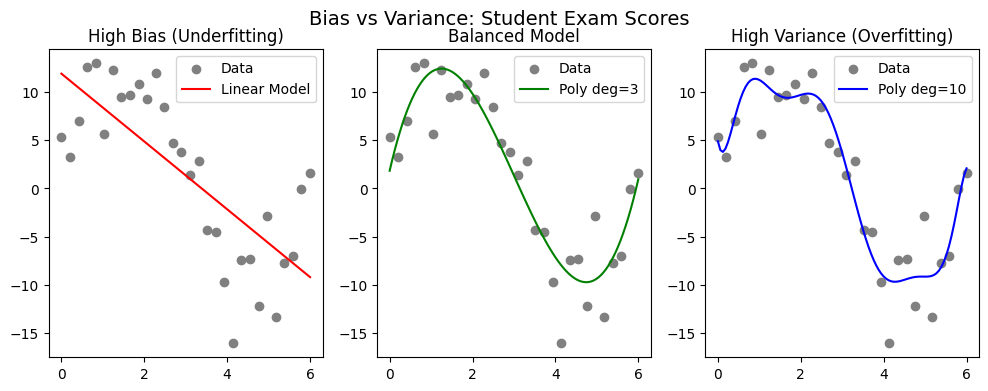

In [ ]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Step 1: Simulate dataset ---
# 30 students, study hours vs exam scores (with noise)
np.random.seed(0)
X = np.linspace(0, 6, 30).reshape(-1, 1)   # study hours
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30)  # exam scores with noise

# --- Step 2: Define models ---
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # simple line
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())  # complex curve
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # "just right"

# --- Step 3: Fit models ---
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

# --- Step 4: Predictions ---
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

# --- Step 5: Plot results ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

Linear (Degree 1)
Train R2: 0.5581353666455768
Test R2: 0.510989271586515
----------------------------------------
Balanced (Degree 3)
Train R2: 0.8666386426057294
Test R2: 0.8386587141781487
----------------------------------------
Polynomial (Degree 10)
Train R2: 0.9087603540057714
Test R2: 0.8501663052416429
----------------------------------------


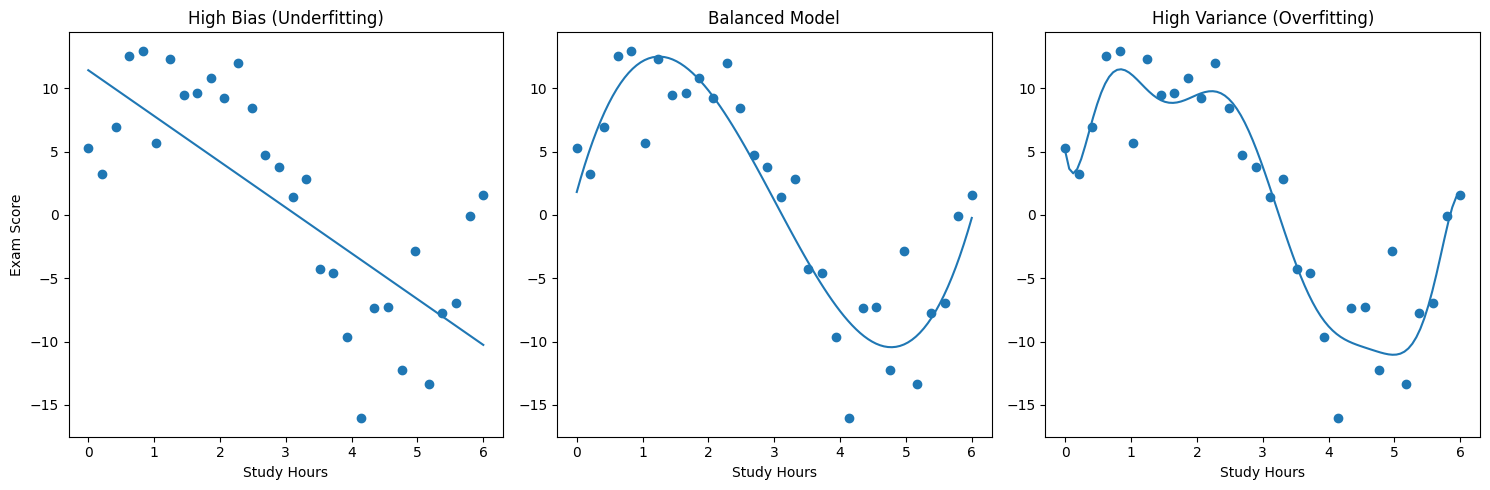

In [ ]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?
# Predicting Student Exam Scores – Bias vs Variance Demonstration

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

np.random.seed(0)

X = np.linspace(0, 6, 30).reshape(-1, 1)
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly_model = make_pipeline(PolynomialFeatures(10), LinearRegression())

linear_model.fit(X_train, y_train)
balanced_model.fit(X_train, y_train)
poly_model.fit(X_train, y_train)

models = {
    "Linear (Degree 1)": linear_model,
    "Balanced (Degree 3)": balanced_model,
    "Polynomial (Degree 10)": poly_model
}

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(name)
    print("Train R2:", r2_score(y_train, y_train_pred))
    print("Test R2:", r2_score(y_test, y_test_pred))
    print("-" * 40)

X_plot = np.linspace(0, 6, 100).reshape(-1, 1)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(X, y)
plt.plot(X_plot, linear_model.predict(X_plot))
plt.title("High Bias (Underfitting)")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")

plt.subplot(1,3,2)
plt.scatter(X, y)
plt.plot(X_plot, balanced_model.predict(X_plot))
plt.title("Balanced Model")
plt.xlabel("Study Hours")

plt.subplot(1,3,3)
plt.scatter(X, y)
plt.plot(X_plot, poly_model.predict(X_plot))
plt.title("High Variance (Overfitting)")
plt.xlabel("Study Hours")

plt.tight_layout()
plt.show()

In [ ]:
# Scenario: Package Delivery System
# A logistics company wants to build a machine learning model to optimize package delivery.
# They collect data about each package, including:
# - Size: Small, Medium, Large
# - Priority: Low, Medium, High
# Since machine learning models work with numbers (not text labels), the company decides to use Label
#  Encoding to convert these categories into numeric values.
# They apply Scikit-learn’s LabelEncoder to both features:
# - Size → converted into numeric codes (e.g., Small = 2, Medium = 1, Large = 0)
# - Priority → converted into numeric codes (e.g., Low = 1, Medium = 2, High = 0)
# They also check the mapping and decode the numbers back to the original labels to ensure correctness.

# Questions for Learners
# Part A: Why does the company need to convert categorical values like Small, Medium, Large into numbers
# before training a model?
# Part B: If the encoded values are 0, 1, 2, does the order (e.g., Large = 0, Medium = 1, Small = 2)
# matter for all models? Why or why not?
# Part C: How can the company decode the numeric values back into the original labels after prediction?
# Part D (Applied): Suppose the company adds a new category “Extra Large.” How would LabelEncoder handle
# this, and what challenge might arise if the model was already trained?
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 1: Sample Data
data = pd.DataFrame({
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small'],
    'Priority': ['Low', 'High', 'Medium', 'Low', 'High']
})

print("Original Data:\n")
print(data)

# Step 2: Create Label Encoders
le_size = LabelEncoder()
le_priority = LabelEncoder()

# Step 3: Fit and Transform
data['Size_Encoded'] = le_size.fit_transform(data['Size'])
data['Priority_Encoded'] = le_priority.fit_transform(data['Priority'])

# Step 4: View Encoding Mapping
print("\nSize mapping:",
      dict(zip(le_size.classes_,
               le_size.transform(le_size.classes_))))

print("Priority mapping:",
      dict(zip(le_priority.classes_,
               le_priority.transform(le_priority.classes_))))

# Step 5: Decode
decoded_size = le_size.inverse_transform([0, 1, 2])
print("\nDecoded Size:", decoded_size)

# Step 6: Final Data
print("\nEncoded DataFrame:")
print(data)

Original Data:

     Size Priority
0   Small      Low
1  Medium     High
2   Large   Medium
3  Medium      Low
4   Small     High

Size mapping: {'Large': np.int64(0), 'Medium': np.int64(1), 'Small': np.int64(2)}
Priority mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Decoded Size: ['Large' 'Medium' 'Small']

Encoded DataFrame:
     Size Priority  Size_Encoded  Priority_Encoded
0   Small      Low             2                 1
1  Medium     High             1                 0
2   Large   Medium             0                 2
3  Medium      Low             1                 1
4   Small     High             2                 0


In [ ]:
# Scenario: Restaurant Ordering System
# A restaurant wants to build a machine learning model to predict order preparation time.
# They collect data about each order, including:
# - Meal Type: Breakfast, Lunch, Dinner
# - Spice Level: Mild, Medium, Hot
# Since models can’t directly work with text labels, the restaurant uses Label Encoding to
# convert these categories into numbers.

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 1: Create Sample Data
data = pd.DataFrame({
    'Meal_Type': ['Breakfast', 'Lunch', 'Dinner', 'Lunch', 'Breakfast'],
    'Spice_Level': ['Mild', 'Hot', 'Medium', 'Mild', 'Hot']
})

print("Original Data:\n")
print(data)

# Step 2: Create Label Encoders
le_meal = LabelEncoder()
le_spice = LabelEncoder()

# Step 3: Fit and Transform
data['Meal_Type_Encoded'] = le_meal.fit_transform(data['Meal_Type'])
data['Spice_Level_Encoded'] = le_spice.fit_transform(data['Spice_Level'])

# Step 4: View Encoding Mapping
print("\nMeal Type Mapping:",
      dict(zip(le_meal.classes_,
               le_meal.transform(le_meal.classes_))))

print("Spice Level Mapping:",
      dict(zip(le_spice.classes_,
               le_spice.transform(le_spice.classes_))))

# Step 5: Decode Back to Original Labels
decoded_meal = le_meal.inverse_transform([0, 1, 2])
decoded_spice = le_spice.inverse_transform([0, 1, 2])

print("\nDecoded Meal Types:", decoded_meal)
print("Decoded Spice Levels:", decoded_spice)

# Step 6: Final Encoded DataFrame
print("\nEncoded DataFrame:\n")
print(data)

Original Data:

   Meal_Type Spice_Level
0  Breakfast        Mild
1      Lunch         Hot
2     Dinner      Medium
3      Lunch        Mild
4  Breakfast         Hot

Meal Type Mapping: {'Breakfast': np.int64(0), 'Dinner': np.int64(1), 'Lunch': np.int64(2)}
Spice Level Mapping: {'Hot': np.int64(0), 'Medium': np.int64(1), 'Mild': np.int64(2)}

Decoded Meal Types: ['Breakfast' 'Dinner' 'Lunch']
Decoded Spice Levels: ['Hot' 'Medium' 'Mild']

Encoded DataFrame:

   Meal_Type Spice_Level  Meal_Type_Encoded  Spice_Level_Encoded
0  Breakfast        Mild                  0                    2
1      Lunch         Hot                  2                    0
2     Dinner      Medium                  1                    1
3      Lunch        Mild                  2                    2
4  Breakfast         Hot                  0                    0


In [ ]:
# Scenario: Employee Training & Satisfaction Survey
# A company conducts a survey to understand how employee education level and job satisfaction affect performance.
# They collect data such as:
# - Education: High School, Bachelor, Master, PhD
# - Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., PhD is higher than Bachelor, Excellent is better
#  than Good), the company decides to use Ordinal Encoding to convert them into numbers that respect
#  this ranking.
# They define custom ordering:
# - Education → High School (0), Bachelor (1), Master (2), PhD (3)
# - Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

# Questions for Learners
# Part A: Why is it important to use Ordinal Encoding instead of simple Label Encoding for ordered
# categories like education level?
# Part B: If the company encoded “PhD = 0” and “High School = 3,” what problem might arise in
# interpreting the model?
# Part C: How does Ordinal Encoding differ from One-Hot Encoding in representing categorical data?
# Part D (Applied): Suppose the company adds a new satisfaction level “Outstanding.” How should they
# update their encoding scheme to keep the order meaningful?
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# ----------------------------------------
# Scenario: Employee Training & Satisfaction Survey
# ----------------------------------------

# A company wants to encode ordered categories (Education, Satisfaction)
# so they can analyze employee performance.

# Step 1: Sample survey data
data = pd.DataFrame({
    'Education': ['Bachelor', 'PhD', 'Master', 'High School'],
    'Satisfaction': ['Good', 'Excellent', 'Poor', 'Average']
})

# Step 2: Define custom ordering
education_order = [['High School', 'Bachelor', 'Master', 'PhD']]
satisfaction_order = [['Poor', 'Average', 'Good', 'Excellent']]

# Step 3: Use OrdinalEncoder for custom ordering
edu_encoder = OrdinalEncoder(categories=education_order)
data['Education_Encoded'] = edu_encoder.fit_transform(data[['Education']])

sat_encoder = OrdinalEncoder(categories=satisfaction_order)
data['Satisfaction_Encoded'] = sat_encoder.fit_transform(data[['Satisfaction']])

# Step 4: Alternative manual mapping with dictionaries
education_map = {
    'High School': 0, 'Bachelor': 1,
    'Master': 2, 'PhD': 3
}

satisfaction_map = {
    'Poor': 0, 'Average': 1,
    'Good': 2, 'Excellent': 3
}

data['Education_Manual'] = data['Education'].map(education_map)
data['Satisfaction_Manual'] = data['Satisfaction'].map(satisfaction_map)

# Step 5: Final encoded dataset
data
print("\nEncoded Survey DataFrame:")
print(data)


Encoded Survey DataFrame:
     Education Satisfaction  Education_Encoded  Satisfaction_Encoded  \
0     Bachelor         Good                1.0                   2.0   
1          PhD    Excellent                3.0                   3.0   
2       Master         Poor                2.0                   0.0   
3  High School      Average                0.0                   1.0   

   Education_Manual  Satisfaction_Manual  
0                 1                    2  
1                 3                    3  
2                 2                    0  
3                 0                    1  


In [ ]:
# Scenario: Patient Health Monitoring
# A hospital wants to analyze patient records to understand how disease severity and recovery
# satisfaction affect treatment outcomes.
# They collect data such as:
# - Disease Severity: Mild, Moderate, Severe, Critical
# - Recovery Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., Critical is worse than Mild, Excellent is
# better than Poor), the hospital uses Ordinal Encoding to convert them into numbers that respect this
#  ranking.
# They define custom ordering:
# - Disease Severity → Mild (0), Moderate (1), Severe (2), Critical (3)
# - Recovery Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# Step 1: Sample patient data
data = pd.DataFrame({
    'Disease_Severity': ['Mild', 'Severe', 'Critical', 'Moderate'],
    'Recovery_Satisfaction': ['Good', 'Excellent', 'Poor', 'Average']
})

# Step 2: Define custom ordering
severity_order = [['Mild', 'Moderate', 'Severe', 'Critical']]
recovery_order = [['Poor', 'Average', 'Good', 'Excellent']]

# Step 3: Apply OrdinalEncoder
severity_encoder = OrdinalEncoder(categories=severity_order)
recovery_encoder = OrdinalEncoder(categories=recovery_order)

data['Severity_Encoded'] = severity_encoder.fit_transform(data[['Disease_Severity']])
data['Recovery_Encoded'] = recovery_encoder.fit_transform(data[['Recovery_Satisfaction']])

# Step 4: Manual dictionary mapping (for comparison)
severity_map = {
    'Mild': 0,
    'Moderate': 1,
    'Severe': 2,
    'Critical': 3
}

recovery_map = {
    'Poor': 0,
    'Average': 1,
    'Good': 2,
    'Excellent': 3
}

data['Severity_Manual'] = data['Disease_Severity'].map(severity_map)
data['Recovery_Manual'] = data['Recovery_Satisfaction'].map(recovery_map)

# Step 5: Final dataset
print("\nEncoded Patient DataFrame:")
print(data)


Encoded Patient DataFrame:
  Disease_Severity Recovery_Satisfaction  Severity_Encoded  Recovery_Encoded  \
0             Mild                  Good               0.0               2.0   
1           Severe             Excellent               2.0               3.0   
2         Critical                  Poor               3.0               0.0   
3         Moderate               Average               1.0               1.0   

   Severity_Manual  Recovery_Manual  
0                0                2  
1                2                3  
2                3                0  
3                1                1  


In [ ]:
# Scenario: Online Food Delivery App
# An online food delivery company wants to build a machine learning model to predict delivery time based
#  on the type of cuisine ordered.
# They collect data such as:
# - Cuisine Type: Italian, Chinese, Indian, Mexican
# Since machine learning models can’t directly work with text labels, the company decides to use One-Hot
#  Encoding.
# This method creates a new column for each cuisine type:
# - Italian → [1, 0, 0, 0]
# - Chinese → [0, 1, 0, 0]
# - Indian → [0, 0, 1, 0]
# - Mexican → [0, 0, 0, 1]
# They set sparse=False so the encoder returns a regular NumPy array instead of a sparse matrix, making
#  the results easier to read and print for analysis.

# Questions for Learners
# Part A: Why is One-Hot Encoding more appropriate than Label Encoding for categories like cuisine type?
# Part B: What does sparse=False do, and why might it be useful in this scenario?
# Part C: If the company adds a new cuisine type (e.g., “Thai”), how will One-Hot Encoding handle it?
# Part D (Applied): What potential problem could arise if the company has hundreds of cuisine types, and
#  how might they solve it?

# Step 0: Import Required Libraries
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Step 1
orders = pd.DataFrame({
    'Cuisine': ['Italian', 'Chinese', 'Indian', 'Mexican', 'Chinese', 'Italian']
})

# Step 2
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(orders[['Cuisine']])

# Step 3
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.categories_[0]
)

# Step 4 (IMPORTANT LINE)
final_data = pd.concat([orders, encoded_df], axis=1)

# Step 5
print("Cuisine Categories:", encoder.categories_)
print("\nEncoded Array:\n", encoded_array)
print("\nFinal Encoded DataFrame:")
print(final_data)


Cuisine Categories: [array(['Chinese', 'Indian', 'Italian', 'Mexican'], dtype=object)]

Encoded Array:
 [[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]

Final Encoded DataFrame:
   Cuisine  Chinese  Indian  Italian  Mexican
0  Italian      0.0     0.0      1.0      0.0
1  Chinese      1.0     0.0      0.0      0.0
2   Indian      0.0     1.0      0.0      0.0
3  Mexican      0.0     0.0      0.0      1.0
4  Chinese      1.0     0.0      0.0      0.0
5  Italian      0.0     0.0      1.0      0.0
